# 1.3 Poroelastic Modeling Basics

This tutorial builds on the acoustic and elastic notebooks with poroelastic physics. It keeps the same flat two-layer geometry and the same `Vp`, `Vs`, and `Rho` elastic-frame values from 1.2, then adds pore-fluid, porosity, tortuosity, hydraulic permeability (`kappa`), and viscosity properties. The result cells compare solid velocity and pore-pressure gathers so the added poroelastic response is visible, not just configured. The final section adds a single-frequency ParaView QC job for inspecting porosity, hydraulic permeability (`kappa`), PML regions, and frequency-domain fields.


## Imports


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
import frequensolve as fs

u = fs.ureg


## What This Adds To Elastic

The workflow still follows the same project/model/job/result pattern, but each layer now has elastic-frame properties plus Biot pore-fluid and transport properties. The result is not just another velocity model: the receiver set includes both solid motion and pore-pressure observables.

By the end, you should be able to distinguish frame properties from fluid/transport properties, pair mechanical and fluid boundary conditions, and inspect poroelastic traces and ParaView fields without changing the basic project structure learned in 1.1.


## Poroelastic Material Properties

`physics="poroelastic:iso"` on each layer tells the solver to use the isotropic elastic frame parameterization (`Vp`, `Vs`, and `Rho`) plus Biot pore-fluid properties. The shared frame properties match 1.2 exactly; the additional poroelastic properties describe the solid grains, pore fluid, storage, and hydraulic transport.

The values below are expressed in the units shown; the permissible-property reference table uses dimensions so it remains independent of a particular unit system.

| Property | Unit | upper_layer | lower_layer | Meaning |
| --- | --- | ---: | ---: | --- |
| `Vp` | km/s | 2.0 | 2.8 | P-wave speed of the drained elastic frame used by this parameterization. |
| `Vs` | km/s | 1.0 | 1.5 | S-wave speed of the elastic frame. |
| `Rho` | g/cm^3 | 2.2 | 2.4 | Bulk density kept consistent with the acoustic and elastic tutorials. |
| `Qp` | dimensionless | 20.0 | 20.0 | P-wave quality factor for frame attenuation. |
| `Qs` | dimensionless | 10.0 | 10.0 | S-wave quality factor for frame attenuation. |
| `k_solid` | GPa | 12.0 | 18.0 | Solid-grain bulk modulus. |
| `k_fluid` | GPa | 2.2 | 2.2 | Pore-fluid bulk modulus. |
| `rho_solid` | g/cm^3 | 2.65 | 2.70 | Solid-grain density. |
| `rho_fluid` | g/cm^3 | 1.0 | 1.0 | Pore-fluid density. |
| `porosity` | dimensionless | 0.30 | 0.18 | Fraction of the frame volume occupied by pore space. |
| `tortuosity` | dimensionless | 2.0 | 2.2 | Inertial path-length factor for fluid motion through the pore network. |
| `kappa` | m^2 | 1.0e-9 | 2.0e-10 | Hydraulic permeability. |
| `viscosity` | Pa*s | 1.0e-3 | 1.0e-3 | Dynamic viscosity of the pore fluid. |

The public poroelastic material vocabulary supports direct modulus input and elastic-frame input. Adaptivity-only fields are omitted here and covered in the meshing tutorials.

| Property | Dimension | Applies to | Required | Short explanation |
| --- | --- | --- | --- | --- |
| `Vp` | L/T | `poroelastic:iso`, `poroelastic:vti`, `poroelastic:tti` | Yes for elastic-frame modes | P-wave speed of the elastic frame. |
| `Vs` | L/T | `poroelastic:iso`, `poroelastic:vti`, `poroelastic:tti` | Yes for elastic-frame modes | S-wave speed of the elastic frame. |
| `Rho` | M/L^3 | `poroelastic:iso`, `poroelastic:vti`, `poroelastic:tti` | Yes for elastic-frame modes | Bulk density used by the elastic-frame parameterization. |
| `epsilon` | 1 | `poroelastic:vti`, `poroelastic:tti` | Required for anisotropic elastic-frame modes | Thomsen-style P-wave anisotropy parameter. |
| `gamma` | 1 | `poroelastic:vti`, `poroelastic:tti` | No | Thomsen-style S-wave anisotropy parameter. |
| `delta` | 1 | `poroelastic:vti`, `poroelastic:tti` | No | Thomsen-style near-vertical P-wave anisotropy parameter. |
| `phi` | angle | `poroelastic:tti` | No | Symmetry-axis azimuth/rotation for tilted transverse isotropy. |
| `theta` | angle | `poroelastic:tti` | No | Symmetry-axis tilt for tilted transverse isotropy. |
| `k_dry` | M/(L*T^2) | `poroelastic:direct`, `poroelastic:direct_jkd` | Yes for direct modes | Drained-frame bulk modulus supplied directly. |
| `mu_dry` | M/(L*T^2) | `poroelastic:direct`, `poroelastic:direct_jkd` | Yes for direct modes | Drained-frame shear modulus supplied directly. |
| `k_solid` | M/(L*T^2) | all poroelastic modes | Yes | Solid-grain bulk modulus. |
| `k_fluid` | M/(L*T^2) | all poroelastic modes | Yes | Pore-fluid bulk modulus. |
| `rho_solid` | M/L^3 | all poroelastic modes | Yes | Solid-grain density. |
| `rho_fluid` | M/L^3 | all poroelastic modes | Yes | Pore-fluid density. |
| `porosity` | 1 | all poroelastic modes | Yes | Pore-volume fraction. |
| `tortuosity` | 1 | all poroelastic modes | Yes | Inertial tortuosity for relative fluid/solid motion. |
| `kappa` | L^2 | all poroelastic modes | Yes | Hydraulic permeability. |
| `viscosity` | M/(L*T) | all poroelastic modes | Yes | Dynamic fluid viscosity. |
| `Qp` | 1 | elastic-frame poroelastic modes | No | P-wave quality factor for attenuation in the frame parameterization. |
| `Qs` | 1 | elastic-frame poroelastic modes | No | S-wave quality factor for attenuation in the frame parameterization. |
| `qk` | 1 | direct poroelastic modes | No | Bulk-modulus quality factor for direct frame attenuation. |
| `qmu` | 1 | direct poroelastic modes | No | Shear-modulus quality factor for direct frame attenuation. |
| `viscous_length` | L | `*_jkd` modes | Yes for JKD modes | Dynamic permeability length scale used by the JKD hydraulic model. |
| `biot_frequency` | 1/T | `*_jkd` modes | No | Optional transition frequency for dynamic hydraulic response. |


## Project, Simulation, And Layered Model

The next cell creates the project-owned poroelastic simulation and attaches the same flat two-layer geometry used in 1.1 and 1.2. The shared `Vp`, `Vs`, and `Rho` frame properties match the elastic tutorial; the additional Biot properties define the pore-fluid and transport response. Keeping the geometry fixed makes the added pressure/relative-fluid behavior easier to identify in the result plots.


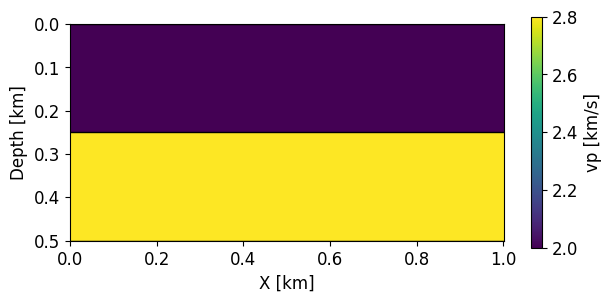

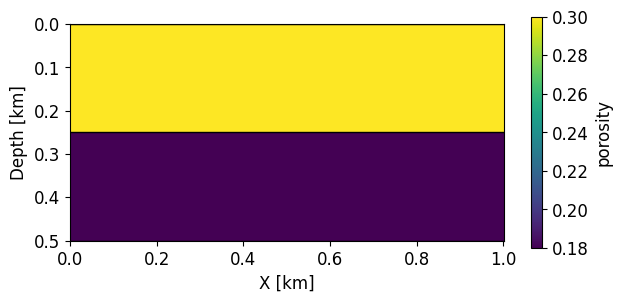

In [2]:
project = fs.Project(
    name="project",
    pretty_name="poroelastic_basic",
    path="./scratch/tutorials/poroelastic_basic",
    log_level="INFO",
    log_to_console=True,
)

sim = project.new_simulation(
    name="poroelastic_basic",
    physics="poroelastic",
    dimension=2,
    units={
        "length": "km",
        "velocity": "km/s",
        "density": "g/cm^3",
    },
)

model = fs.LayeredModel(name="model", dimension=2, x_limits=[0.0, 1.0])
model.add_surface(name="top", depth=0.0 * u.km)
model.add_layer(
    name="upper_layer",
    physics="poroelastic:iso",
    properties={
        "Vp": 2.0 * u.km / u.s,
        "Qp": 20.0,
        "Vs": 1.0 * u.km / u.s,
        "Qs": 10.0,
        "Rho": 2.2 * u.g / u.cm**3,
        "k_solid": 12.0 * u.GPa,
        "k_fluid":  2.2 * u.GPa,
        "rho_solid": 2.65 * u.g / u.cm**3,
        "rho_fluid": 1.0 * u.g / u.cm**3,
        "porosity": 0.30,
        "tortuosity": 2.0,
        "kappa": 1.0e-9 * u.m**2,
        "viscosity": 1.0e-3 * u.Pa * u.s,
    },
)
model.add_surface(name="interface", depth=0.25 * u.km)
model.add_layer(
    name="lower_layer",
    physics="poroelastic:iso",
    properties={
        "Vp": 2.8 * u.km / u.s,
        "Qp": 20.0,
        "Vs": 1.5 * u.km / u.s,
        "Qs": 10.0,
        "Rho": 2.4 * u.g / u.cm**3,
        "k_solid": 18.0 * u.GPa,
        "k_fluid":  2.2 * u.GPa,
        "rho_solid": 2.70 * u.g / u.cm**3,
        "rho_fluid": 1.0 * u.g / u.cm**3,
        "porosity": 0.18,
        "tortuosity": 2.2,
        "kappa": 2.0e-10 * u.m**2,
        "viscosity": 1.0e-3 * u.Pa * u.s,
    },
)
model.add_surface(name="bottom", depth=0.5 * u.km)
sim += model
model.plot("vp", figsize=(7, 3), aspect="equal")
model.plot("porosity", figsize=(7, 3), aspect="equal")


## Mesh, Order, And Wavelength Sizing

The generated mesh starts from the same coarse two-layer geometry used in the acoustic and elastic tutorials. `sim.mesh.set_adapt(...)` asks the solver to refine for the requested frequency band using `order=4` and `elems_per_wave=2`, which corresponds to roughly nine nodal points per shortest wavelength.

PML regions are auto-extruded outside boundaries marked `pml`; they are not authored as extra poroelastic layers. The width is specified in wavelengths with `pml_wavelengths`, so the physical thickness is frequency-dependent and changes with solve frequency and local wave speed.


## Boundary Conditions And PML

Poroelastic boundaries often combine a mechanical condition with a fluid condition. `conditions=["free", "sealed"]` expresses a traction-free surface with no normal relative fluid flow on the top boundary. Replacing `sealed` with `drained` would instead set the pore-pressure trace to zero.

| Boundary condition | Variables/components constrained | Typical use |
| --- | --- | --- |
| `free` | Mechanical traction trace `t_hat = 0`. | Traction-free solid frame, often paired with `sealed` or `drained` for the pore fluid. |
| `fixed` | Mechanical displacement trace `u_hat = 0` for constrained components. | Rigid frame boundary. |
| `sealed` | Normal relative fluid-flux trace `q_hat = 0`. | Undrained or sealed pore boundary. |
| `drained` | Pore-pressure trace `p_hat = 0`. | Drained pore boundary with pressure released at the surface. |
| `impedance` | Couples primary and flux/traction traces through an impedance relation where supported. | Approximate radiation or absorbing behavior without a full PML. |
| `pml` | Absorbing-layer equations for all active poroelastic fields in the auto-extruded PML region. | Truncating the computational domain on sides and bottom. |
| `symmetric` | Symmetry-axis regularity for the active mechanical and fluid variables. | Symmetry-reduced poroelastic models. |

The side and bottom boundaries use `pml_wavelengths=0.75`. That value is a compact tutorial setting; for production poroelastic runs, inspect the ParaView PML output and job logs before tightening `pml_reflection` below its default `1e-3`.


In [3]:
sim += model.hex_mesh_generator([8, 4])
sim.mesh.set_adapt(elems_per_wave=2.0, order=4, f_low=5.0, f_high=30.0)
sim.mesh.set_source_grading(d1=0.05, mult=2.0)

sim += fs.BoundaryCondition(
    conditions=["free", "sealed"],
    boundaries=["z_min"],
)
sim += fs.BoundaryCondition(
    conditions="pml",
    boundaries=["x_min", "x_max", "z_max"],
    pml_wavelengths=0.75,
)


## Acquisition

The source is vector-valued, matching a vertical point force. The receiver device records two components at the same coordinates: vertical solid velocity and pore pressure. This is a useful first poroelastic QC view because velocity shows the frame motion while pore pressure shows the fluid-pressure response.


In [4]:
acq = fs.Acquisition()
acq.add_source_group(kind="vector", coords=[[0.5, 0.0]], direction=[0.0, 1.0])

receiver = fs.ReceiverNode(name="geophone")
receiver.add_component(name="v_z", field="velocity", direction=[0.0, 1.0])
receiver.add_component(name="pore_pressure", field="pressure")
receiver_coords = [[x, 0.0] for x in np.linspace(0.0, 1.0, 201)]

acq.add_receiver_group(name="surface", device=receiver, coords=receiver_coords)
sim += acq

## Run The Poroelastic Job

This cell submits a strict local run. Solver-side issues are intentionally not hidden by the notebook so setup or physics failures remain visible.


In [5]:
site = fs.LocalSite(shutdown_on_completion=True, verbose=True)
job = fs.TimeDomainJob(
    name="time_poroelastic",
    simulation=sim,
    f_min=0.0,
    f_max=45.0,
    T_max=1.0,
)
result = site.submit(job).wait()
traces = result.traces(upscale=4)
traces.summary


2026-05-14 02:39:25,304 [INFO] frequensolve.orchestrator.sites.local:228 - Skipping job time_poroelastic; fingerprint matches and expected trace outputs exist.
2026-05-14 02:39:25,424 [INFO] frequensolve.orchestrator.sites.local:382 - LocalSite: skipped - Run is current


LocalSite: skipped - Run is current


surface
  Receivers	: 1 - 201
  Shot		: 1
  Components	: ['v_z' 'pore_pressure']
  Frequencies	: 1.00 - 45.00 Hz (Δf=1.00)
  Window	: 0.00 - 1.00 s

## Plot Trace Gathers And Center Traces

The trace API is the same as in acoustic and elastic simulations: read the completed result as a `TraceDataset`, select a group/component/source, and pass the returned `xarray.DataArray` to a plotting helper. Plotting both components side by side makes the different poroelastic observables explicit.


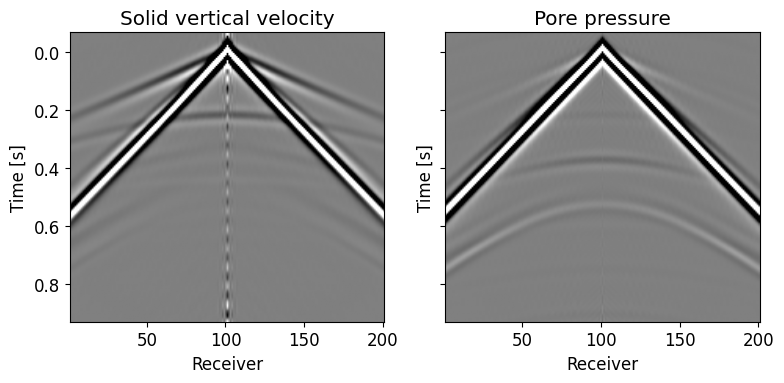

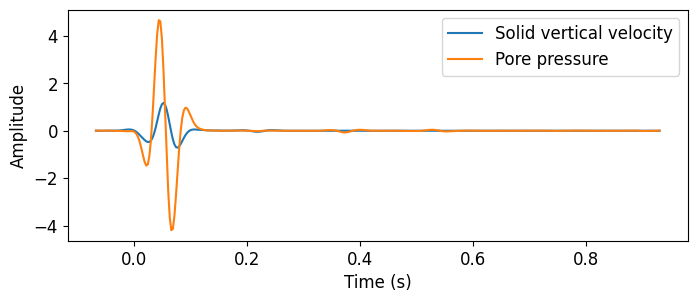

In [6]:
wavelet = fs.RickerWavelet(f=15.0)
group = "surface"
source = traces.sources(group)[0]
components = [
    ("v_z", "Solid vertical velocity"),
    ("pore_pressure", "Pore pressure"),
]

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
gathers = {}
for ax, (component, title) in zip(axes, components):
    gather = traces.td(group, component, source, wavelet, upscale=4, T_max=2.0)
    gathers[component] = gather
    fs.plot_gather(
        gather,
        ax=ax,
        A=np.std(np.abs(gather.values)),
        cmap="gray",
        title=title,
    )
fig.tight_layout()

center = len(receiver_coords) // 2 + 10
fig, ax = plt.subplots(figsize=(8, 3))
for component, label in components:
    trace = gathers[component].isel(receiver=center)
    ax.plot(trace["time"].values, np.real(trace.values), label=label)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.legend()


## Single-Frequency ParaView QC

The time-domain job writes receiver traces. ParaView output is owned by a separate frequency-domain job, which keeps visualization products tied to the frequency and output request that created them. This QC job writes poroelastic fields together with frame properties, porosity, hydraulic permeability (`kappa`), subdomain labels, and the PML region.


In [7]:
site_fd = fs.LocalSite(shutdown_on_completion=True, verbose=True)
poro_pv_output = fs.ParaviewOutput(
    name="pv_poroelastic",
    path="paraview",
    fields=["pressure", "velocity", "p_hat"],
    properties=["vp", "vs", "rho", "porosity", "kappa"],
    sources=[1,2],
    show_pml=True,
    upscale=1,
    order=2,
)

fd_job = fs.FrequencyDomainJob(
    name="freq_poroelastic_qc",
    simulation=sim,
    f_list=[45.0],
    outputs=[poro_pv_output],
)
fd_result = site_fd.submit(fd_job).wait()
poro_vtu_files = fd_result.output_files(base="pv_poroelastic", suffix=".vtu", existing=True)
poro_vtu_files


2026-05-14 02:39:25,812 [INFO] frequensolve.orchestrator.sites.local:228 - Skipping job freq_poroelastic_qc; fingerprint matches and expected trace outputs exist.
2026-05-14 02:39:25,817 [INFO] frequensolve.orchestrator.sites.local:382 - LocalSite: skipped - Run is current


LocalSite: skipped - Run is current


[PosixPath('scratch/tutorials/poroelastic_basic/jobs/poroelastic_basic/freq_poroelastic_qc/results/paraview/pv_poroelastic_00000.vtu'),
 PosixPath('scratch/tutorials/poroelastic_basic/jobs/poroelastic_basic/freq_poroelastic_qc/results/ParaView/pv_poroelastic_00000.vtu')]

## Render The Poroelastic VTU

The files above can be opened directly in ParaView. This notebook preview renders porosity because it is one of the poroelastic properties added on top of the shared acoustic/elastic background model.


In [8]:
image_dir = Path("./tutorial_assets")
image_dir.mkdir(exist_ok=True)

poro_screenshot = image_dir / "poroelastic_paraview_porosity.png"
fs.plot_vtu(
    poro_vtu_files[0],
    field="porosity",
    show_edges=True,
    scalar_bar=True,
    show=False,
    screenshot=poro_screenshot,
    window_size=(1100, 500),
)
display(Image(filename=str(poro_screenshot)))


## Result Review Checklist

Poroelastic review should separate the elastic-frame baseline from the additional fluid/transport response. The goal is not just to export more properties, but to inspect observables that only exist because poroelastic physics is active.

| Artifact | What it proves |
| --- | --- |
| Poroelastic property table | Shared `Vp`/`Vs`/`Rho` values match the elastic baseline while Biot properties add pore-fluid behavior. |
| Solid-velocity gather | Mechanical motion is still available through the familiar trace workflow. |
| Pore-pressure gather | The run produced a poroelastic-specific observable rather than only elastic motion. |
| Porosity/`kappa` VTU output | ParaView output includes transport properties and PML regions for QC. |
| Boundary-condition table | Mechanical and fluid boundary conditions were chosen deliberately, not inherited blindly from acoustic/elastic examples. |
